Logistic Regression

In [263]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import numpy as np
import os
import pandas as pd 

In [264]:
import pandas as pd
use_cols = ['Created Date','Closed Date','Complaint Type','Agency','Borough','Descriptor']
df = pd.read_csv('../dsml-project-team/311-service-requests-from-2010-to-present.csv', usecols=use_cols, nrows=500000)


In [265]:
df

,Created Date,Closed Date,Agency,Complaint Type,Descriptor,Borough
0,2019-12-01T02:04:01.000,NaN,DOT,Street Condition,Pothole,MANHATTAN
1,2019-12-01T01:59:41.000,NaN,NYPD,Noise - Commercial,Loud Music/Party,BROOKLYN
2,2019-12-01T01:59:08.000,NaN,NYPD,Noise - Residential,Loud Music/Party,BROOKLYN
3,2019-12-01T01:58:23.000,NaN,NYPD,Noise - Residential,Loud Music/Party,QUEENS
4,2019-12-01T01:58:07.000,NaN,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS
...,...,...,...,...,...,...
499995,2019-09-22T11:39:38.000,2019-09-22T20:09:28.000,NYPD,Blocked Driveway,Partial Access,QUEENS
499996,2019-09-22T11:39:25.000,2019-09-26T13:02:49.000,DPR,Overgrown Tree/Branches,Hitting Building,BRONX
499997,2019-09-22T11:39:20.000,NaN,TLC,For Hire Vehicle Complaint,Driver Complaint - Non Passenger,MANHATTAN
499998,2019-09-22T11:38:28.000,2019-09-22T12:16:31.000,NYPD,Noise - Residential,Banging/Pounding,BROOKLYN


In [266]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date']  = pd.to_datetime(df['Closed Date'], errors='coerce')


In [267]:
print(df['Created Date'])

0        2019-12-01 02:04:01
1        2019-12-01 01:59:41
2        2019-12-01 01:59:08
3        2019-12-01 01:58:23
4        2019-12-01 01:58:07
                 ...        
499995   2019-09-22 11:39:38
499996   2019-09-22 11:39:25
499997   2019-09-22 11:39:20
499998   2019-09-22 11:38:28
499999   2019-09-22 11:38:12
Name: Created Date, Length: 500000, dtype: datetime64[ns]


In [268]:
print(df['Closed Date'])

0                        NaT
1                        NaT
2                        NaT
3                        NaT
4                        NaT
                 ...        
499995   2019-09-22 20:09:28
499996   2019-09-26 13:02:49
499997                   NaT
499998   2019-09-22 12:16:31
499999                   NaT
Name: Closed Date, Length: 500000, dtype: datetime64[ns]


Text Cleaning

In [269]:
df.isnull().sum()

Created Date          0
Closed Date       57084
Agency                0
Complaint Type        0
Descriptor        11274
Borough               0
dtype: int64

In [270]:

# Handle missing values
df['Complaint Type'] = df['Complaint Type'].fillna('')
df['Descriptor'] = df['Descriptor'].fillna('')
df['Borough'] = df['Borough'].fillna('Unknown')

In [271]:
# Combine complaint type and descriptor
df['text'] = df['Complaint Type'] + " " + df['Descriptor']

In [272]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [273]:
# Text Cleaning

def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    
    text = re.sub(r"http\S+|www\S+", '', text)  # Remove URLs

    
    text = re.sub(r"[^a-z\s]", '', text)  # Remove special characters
    
    words = text.split()
    
    # Remove stopwords + apply lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [274]:

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,Street Condition Pothole,street condition pothole
1,Noise - Commercial Loud Music/Party,noise commercial loud musicparty
2,Noise - Residential Loud Music/Party,noise residential loud musicparty
3,Noise - Residential Loud Music/Party,noise residential loud musicparty
4,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking


In [275]:
def clean_text(text):
    if pd.isna(text):
        return ""
    return text.lower()

df['cleaned_text'] = df['Descriptor'].apply(clean_text)

df.to_csv("../dsml-project-team/cleaned_data.csv", index=False)

In [243]:
# Convert date columns
for date_col in ['Created Date','Closed Date']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

In [244]:
threshold = 0.7 * len(df)
df = df.dropna(axis=1, thresh=threshold)

In [245]:
if 'Created Date' in df.columns:
    df['year'] = df['Created Date'].dt.year
    df['month'] = df['Created Date'].dt.month
    df['day'] = df['Created Date'].dt.day
    df['hour'] = df['Created Date'].dt.hour

In [246]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [247]:
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [248]:
if 'Created Date' in df.columns and 'Closed Date' in df.columns:
    df['response_time_hours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds()/3600

In [249]:
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [250]:
# Drop rows where Closed Date is missing (for regression target)
df = df.dropna(subset=['Closed Date'])

# Recalculate response time
df['response_time_hours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds()/3600


In [251]:
df.isnull().sum()

Created Date           0
Closed Date            0
Agency                 0
Complaint Type         0
Descriptor             0
Borough                0
text                   0
clean_text             0
year                   0
month                  0
day                    0
hour                   0
response_time_hours    0
dtype: int64

In [19]:
import seaborn as sns

In [20]:
colors = sns.color_palette("husl", 10)

In [21]:
sns.set_style("whitegrid")
sns.set_palette("husl")

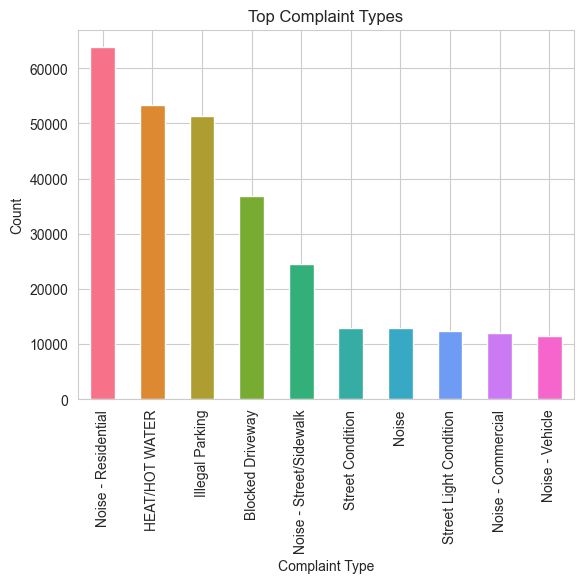

In [22]:
df['Complaint Type'].value_counts().head(10).plot(kind='bar', color=colors)
plt.title("Top Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.show()

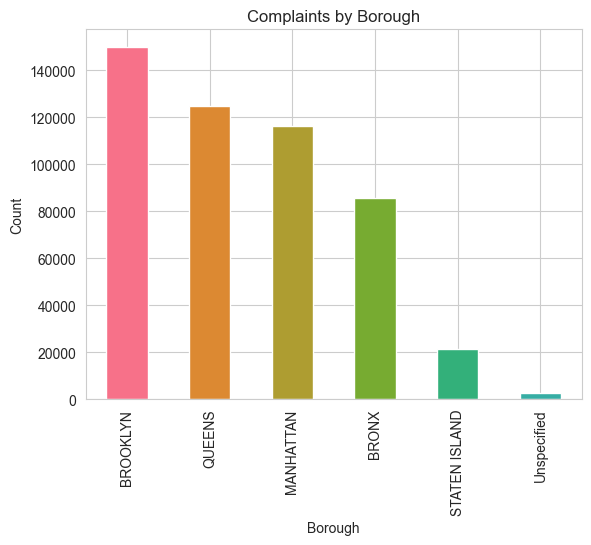

In [23]:
# Borough Analsis

df['Borough'].value_counts().plot(kind='bar', color=colors)
plt.title("Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.show()

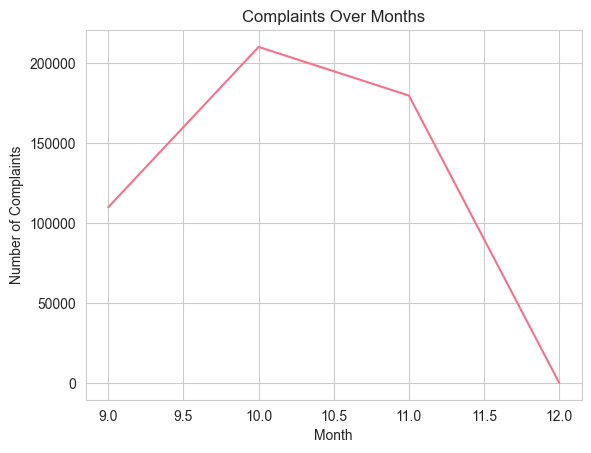

In [24]:
# Time Analysis

df['Created Date'] = pd.to_datetime(
    df['Created Date'], 
    format='%m/%d/%y %H:%M:%S', 
    errors='coerce')

df['Created Date'].dt.month.value_counts().sort_index().plot()
plt.title("Complaints Over Months")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.show()

In [28]:
from wordcloud import WordCloud

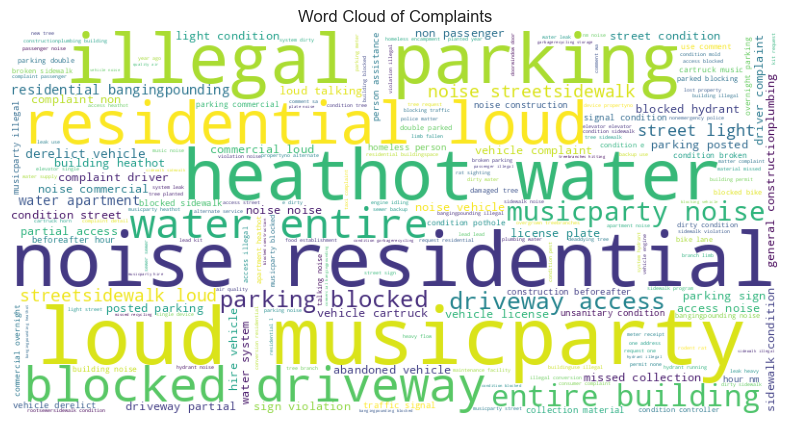

In [29]:
# Word Cloud 
text_data = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Complaints")
plt.show()

In [31]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer

In [32]:
# N-grams(Unigrams) 

vectorizer = CountVectorizer(ngram_range=(1,1), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

unigram_df = pd.DataFrame({'word': words, 'count': counts})
unigram_df.sort_values(by='count', ascending=False)

,word,count
6,noise,140465
4,loud,82387
7,parking,76259
9,water,75676
8,residential,70525
5,musicparty,69365
1,condition,65220
0,blocked,63536
3,illegal,59516
2,heathot,53381


In [33]:
#Bigrams

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({'bigram': bigrams, 'count': counts})
bigram_df.sort_values(by='count', ascending=False)

,bigram,count
5,loud musicparty,69365
6,noise residential,63813
3,heathot water,53381
4,illegal parking,51356
8,residential loud,46530
0,blocked driveway,36795
9,water entire,36184
2,entire building,36184
1,driveway access,26616
7,parking blocked,25129


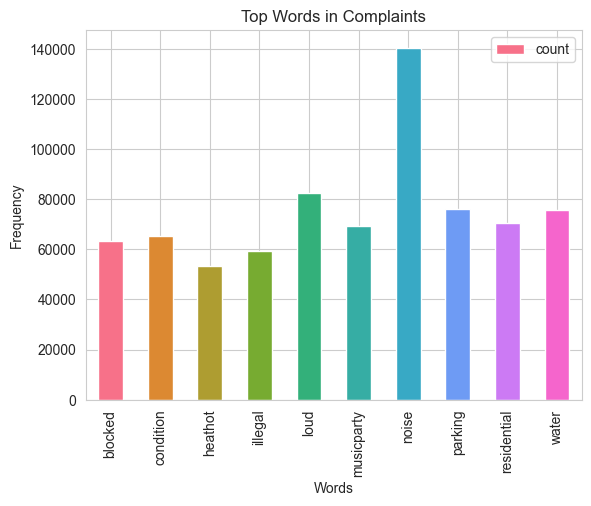

In [34]:
unigram_df.plot(x='word', y='count', kind='bar', color=colors)
plt.title("Top Words in Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

Random Forest Regression

In [52]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt 
import numpy as np
import os
import pandas as pd 
import seaborn as sns

In [61]:
use_cols = ['Created Date','Closed Date','Complaint Type','Agency','Borough','Descriptor']
nRowsRead = 500000
df1 = pd.read_csv('../dsml-project-team/311-service-requests-from-2010-to-present.csv', usecols=use_cols, nrows = nRowsRead)
df1.dataframeName = '311-service-requests-from-2010-to-present.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 500000 rows and 6 columns


In [62]:
df1.head(10)

,Created Date,Closed Date,Agency,Complaint Type,Descriptor,Borough
0,2019-12-01T02:04:01.000,NaN,DOT,Street Condition,Pothole,MANHATTAN
1,2019-12-01T01:59:41.000,NaN,NYPD,Noise - Commercial,Loud Music/Party,BROOKLYN
2,2019-12-01T01:59:08.000,NaN,NYPD,Noise - Residential,Loud Music/Party,BROOKLYN
3,2019-12-01T01:58:23.000,NaN,NYPD,Noise - Residential,Loud Music/Party,QUEENS
4,2019-12-01T01:58:07.000,NaN,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS
5,2019-12-01T01:57:49.000,NaN,NYPD,Noise - Residential,Loud Music/Party,MANHATTAN
6,2019-12-01T01:57:48.000,NaN,NYPD,Noise - Residential,Banging/Pounding,BRONX
7,2019-12-01T01:57:30.000,NaN,NYPD,Noise - Commercial,Loud Music/Party,MANHATTAN
8,2019-12-01T01:57:30.000,NaN,TLC,Taxi Complaint,Driver Complaint - Non Passenger,MANHATTAN
9,2019-12-01T01:57:21.000,NaN,NYPD,Noise - Residential,Loud Music/Party,MANHATTAN


In [63]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Created Date    500000 non-null  object
 1   Closed Date     442916 non-null  object
 2   Agency          500000 non-null  object
 3   Complaint Type  500000 non-null  object
 4   Descriptor      488726 non-null  object
 5   Borough         500000 non-null  object
dtypes: object(6)
memory usage: 22.9+ MB


In [64]:
df1.describe()

,Created Date,Closed Date,Agency,Complaint Type,Descriptor,Borough
count,500000,442916,500000,500000,488726,500000
unique,186674,125852,14,152,717,6
top,2019-09-23T07:00:00.000,2019-09-24T00:00:00.000,NYPD,Noise - Residential,Loud Music/Party,BROOKLYN
freq,121,1067,223577,63813,69365,149790


In [65]:
df1.isnull().sum()

Created Date          0
Closed Date       57084
Agency                0
Complaint Type        0
Descriptor        11274
Borough               0
dtype: int64

Missing Value Handling

In [68]:
df['Created Date'] = pd.to_datetime(df1['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df1['Closed Date'], errors='coerce')

In [124]:
# Handle Closed Date nulls
df = df.dropna(subset=['Created Date'])   # must have Created Date
df['Closed Date'] = df['Closed Date'].fillna(pd.Timestamp.now())

In [125]:
# Fill numeric with median, categorical with mode
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [129]:
# Text cleaning
import re
def clean_text(text):
    if pd.isna(text): 
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                # keep only letters
    tokens = [word for word in text.split() if len(word) > 2]
    return " ".join(tokens)

In [130]:
# Convert date columns
for date_col in ['Created Date','Closed Date']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

In [131]:
# Extract year, month, day, hour
if 'Created Date' in df.columns:
    df['year'] = df['Created Date'].dt.year
    df['month'] = df['Created Date'].dt.month
    df['day'] = df['Created Date'].dt.day
    df['hour'] = df['Created Date'].dt.hour

In [132]:
# Encode categorical variables
cat_cols = ['Complaint Type','Agency','Borough','Descriptor']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

Univariate Analysis

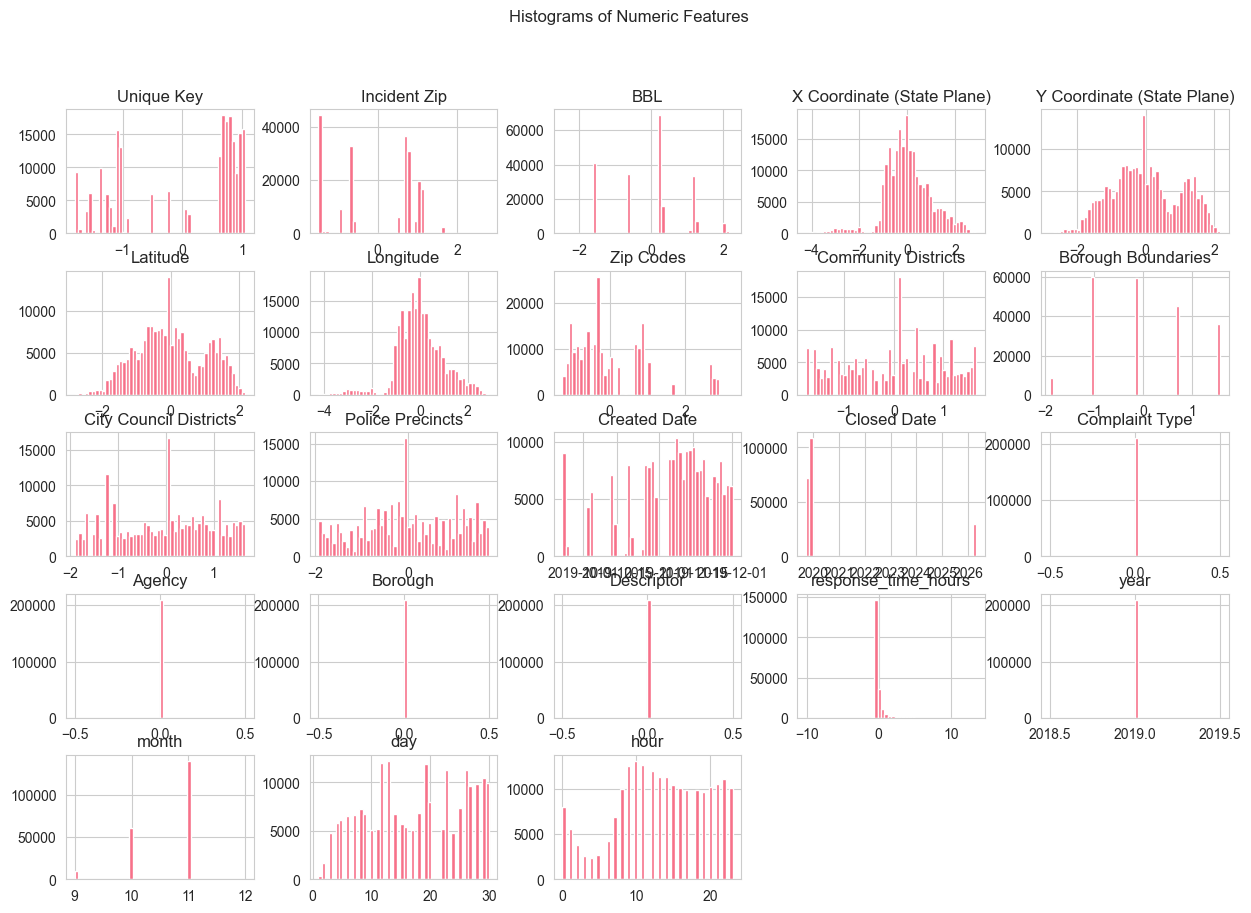

In [133]:
df.hist(figsize=(15,10), bins=50)
plt.suptitle("Histograms of Numeric Features")
plt.show()

Correlation Matrix

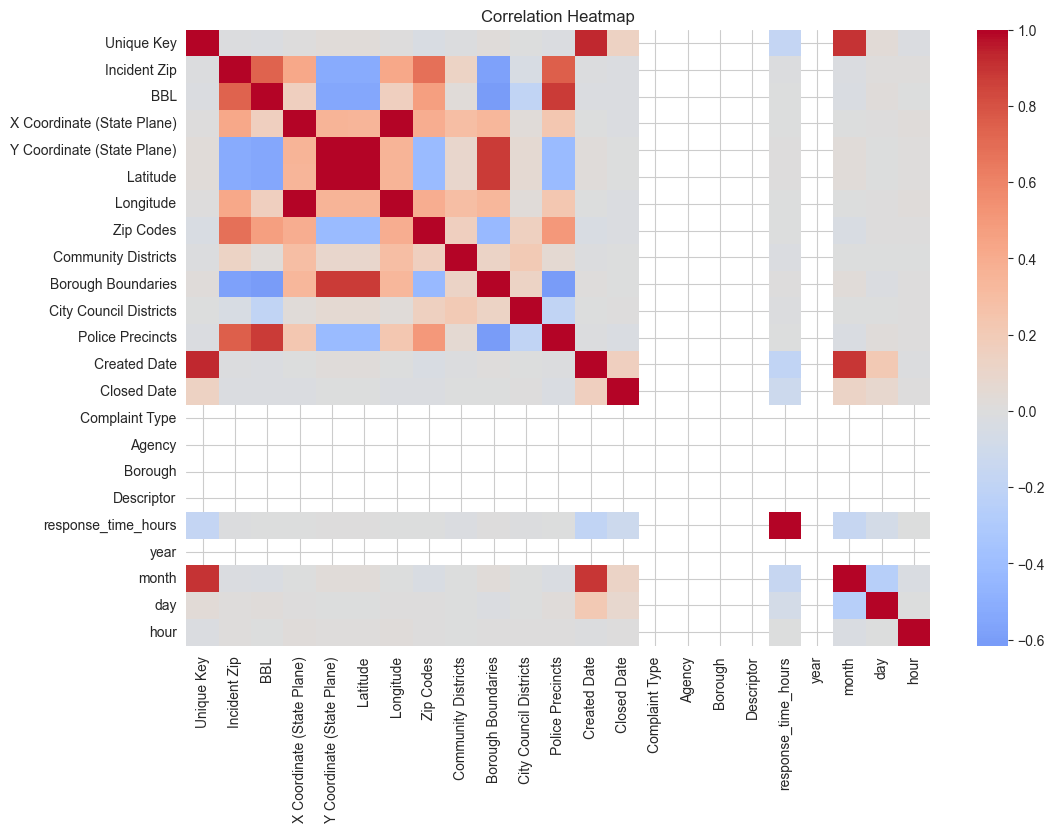

In [134]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

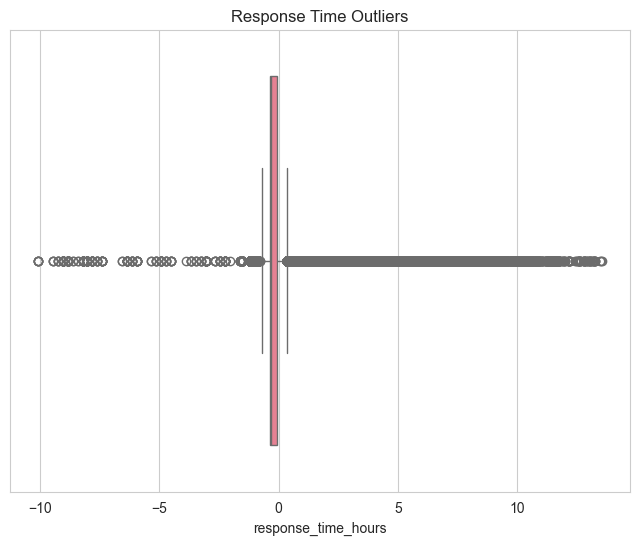

In [135]:
if 'response_time_hours' in df.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df['response_time_hours'])
    plt.title("Response Time Outliers")
    plt.show()

Scaling

In [136]:
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [137]:
df[num_cols]


,Unique Key,Incident Zip,BBL,X Coordinate (State Plane),Y Coordinate (State Plane),Latitude,Longitude,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts,Complaint Type,Agency,Borough,Descriptor,response_time_hours
0,1.041132,-1.487453,0.236325,-0.801693,0.164496,0.165119,-0.802478,-0.283309,0.094905,-0.166483,0.091975,-0.045436,0.0,0.0,0.0,0.0,-0.302579
1,1.052679,0.745164,0.283778,-0.672685,-1.631488,-1.630869,-0.674023,-0.283309,0.094905,-0.166483,0.091975,-0.045436,0.0,0.0,0.0,0.0,-0.302579
2,1.039289,0.715932,0.258928,0.538293,-0.858807,-0.858875,0.536511,-0.283309,0.094905,-0.166483,0.091975,-0.045436,0.0,0.0,0.0,0.0,-0.302579
3,1.045777,0.991811,1.166969,1.520078,0.338890,0.337569,1.521412,-0.283309,0.094905,-0.166483,0.091975,-0.045436,0.0,0.0,0.0,0.0,-0.302579
4,1.052830,1.116049,1.190211,2.508305,-0.026353,-0.029530,2.508941,-0.283309,0.094905,-0.166483,0.091975,-0.045436,0.0,0.0,0.0,0.0,-0.302579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,-1.792024,1.097778,1.200258,0.965168,-0.606170,-0.606702,0.963738,2.692673,0.439074,-0.166483,0.949800,0.915797,0.0,0.0,0.0,0.0,-0.298510
399996,-1.788260,-0.636062,-0.649059,0.534308,1.779840,1.779718,0.537450,-0.824139,-0.642600,1.573276,0.878315,-0.333806,0.0,0.0,0.0,0.0,0.466688
399997,-1.781941,-1.465529,-1.572351,-1.060080,-0.092965,-0.092334,-1.061008,-0.690632,0.979912,0.703396,-1.266248,-1.919842,0.0,0.0,0.0,0.0,-0.302579
399998,-1.783324,0.715932,0.259333,0.575271,-0.887883,-0.887987,0.573412,0.765754,0.389907,-1.036363,-0.193967,0.290995,0.0,0.0,0.0,0.0,-0.366195


In [138]:
num_cols

Index(['Unique Key', 'Incident Zip', 'BBL', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Latitude', 'Longitude', 'Zip Codes',
       'Community Districts', 'Borough Boundaries', 'City Council Districts',
       'Police Precincts', 'Complaint Type', 'Agency', 'Borough', 'Descriptor',
       'response_time_hours'],
      dtype='object')

In [139]:
df.isnull().sum()

Unique Key                    0
Incident Zip                  0
BBL                           0
X Coordinate (State Plane)    0
Y Coordinate (State Plane)    0
Latitude                      0
Longitude                     0
Zip Codes                     0
Community Districts           0
Borough Boundaries            0
City Council Districts        0
Police Precincts              0
Created Date                  0
Closed Date                   0
Complaint Type                0
Agency                        0
Borough                       0
Descriptor                    0
response_time_hours           0
year                          0
month                         0
day                           0
hour                          0
dtype: int64